<a href="https://colab.research.google.com/github/mail2venkie/fastbook/blob/temp/myclean/06_multicat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#hide
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

Mounted at /content/gdrive


In [3]:
#hide
from fastbook import *

In [4]:
from fastai.vision.all import *
path = untar_data(URLs.PASCAL_2007)
path.ls()

(#8) [Path('/root/.fastai/data/pascal_2007/train'),Path('/root/.fastai/data/pascal_2007/test'),Path('/root/.fastai/data/pascal_2007/train.csv'),Path('/root/.fastai/data/pascal_2007/train.json'),Path('/root/.fastai/data/pascal_2007/test.csv'),Path('/root/.fastai/data/pascal_2007/segmentation'),Path('/root/.fastai/data/pascal_2007/valid.json'),Path('/root/.fastai/data/pascal_2007/test.json')]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

My trials
** START **

In [4]:
def get_x(df):
  return path/'train'/df['fname']

def get_y(df):
  return df['labels'].split(' ')

def splitter(df):
  train = df.index[~df['is_valid']].tolist()
  valid = df.index[df['is_valid']].tolist()
  return train, valid

In [6]:
df = pd.read_csv(path/'train.csv')

First create a DataBlock. This is the starting point for everything.

Datablock yields a DataLoaders object which is the provides the actual load functionality.  

In [7]:
dblk = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    get_x=get_x,
    get_y=get_y,
    splitter=splitter,
    item_tfms=RandomResizedCrop(128, min_scale=0.35)
)
dls = dblk.dataloaders(df)

Eye balling a few images and labels.

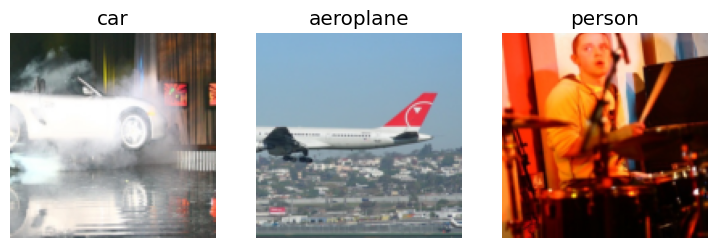

In [67]:
dls.show_batch(nrows=1, ncols=3)

Datablock is used to return a DataSet. The Dataset contains the data split as well as the vocabulary for the model.

In [87]:
dsets = dblk.datasets(df)
dsets.train.vocab, len(dsets.train.vocab)

(['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'],
 20)

Checking whether the labels are picked up correctly. 20 labels from the csv file:

`cut -d"," -f2 train.csv | sed "s/ /\n/g" | sort | uniq | grep -v labels | wc -l`

Matches with `len(dsets.train.vocab)`

Multi category tensor from the MultiCategoryBlock can be seen from the dataset.

In [88]:
dsets.train[0]

(PILImage mode=RGB size=500x333,
 TensorMultiCategory([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

Add a metric. By inspecting the `metrics.py` program, the default error_rate function is just `1 - accuracy`. But we will have to define accuracy for this multi category dataset.
`accuracy_multi` is useful in this case

In [81]:
learner = None
learner = vision_learner(dls=dls, arch=resnet50, metrics=error_rate)

In [82]:
x,y= to_cpu(dls.one_batch())
activations = learner.model(x)
activations

TensorImage([[ 1.4582, -0.4066, -0.1614,  ..., -0.4531, -0.0452, -3.1699],
             [ 1.4154, -1.0802,  1.4999,  ..., -4.8779,  2.4697, -3.1087],
             [-2.7670,  0.6654, -2.2079,  ..., -0.1140,  0.5792,  0.5160],
             ...,
             [ 1.7643, -0.8185, -0.8733,  ..., -0.4766,  0.2792,  2.3239],
             [-1.6500,  0.0546,  1.6702,  ..., -0.5133,  0.3960,  4.9499],
             [ 0.8455,  1.1311,  1.8725,  ..., -0.8923,  1.2467,  0.4642]], grad_fn=<AliasBackward0>)

In [86]:
activations.shape

torch.Size([64, 20])

In [19]:
learner = None
learner = vision_learner(
    dls = dls,
    arch = resnet50,
    metrics = partial(accuracy_multi, thresh = 0.6)
)

In [20]:
learner.fine_tune(
    epochs = 3,
    base_lr = 3e-3,
    freeze_epochs = 4
)

epoch,train_loss,valid_loss,accuracy_multi,time
0,0.962862,0.704769,0.732988,00:19
1,0.834523,0.545606,0.844064,00:21
2,0.607617,0.199334,0.959522,00:19
3,0.361386,0.118096,0.961634,00:22


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.128964,0.104324,0.965239,00:20
1,0.113177,0.096611,0.967410,00:22
2,0.097077,0.097031,0.966335,00:20


In [14]:
preds,targs = learner.get_preds()

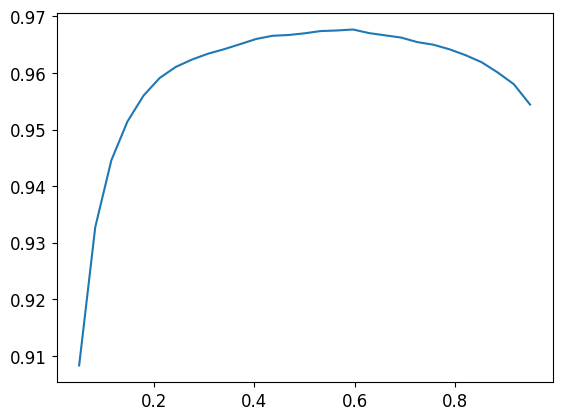

In [18]:
xs = torch.linspace(0.05, 0.95,29)
accuracies = [accuracy_multi(preds, targs, thresh=i, sigmoid=False) for i in xs]
plt.plot(xs, accuracies)

In [21]:
learner.export()

In [4]:
learner_inf = load_learner('06_multicat_model.pkl')

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


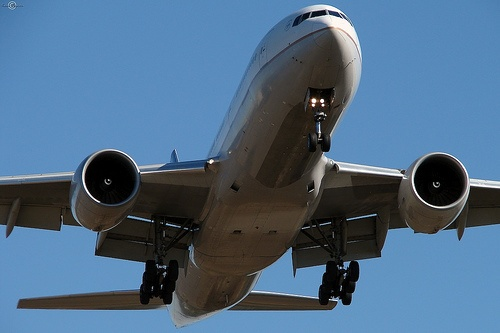

In [5]:
im = Image.open(path/'test/009329.jpg')
im

In [6]:
x,y,z = learner_inf.predict(im)

In [7]:
x

(#1) ['aeroplane']

In [12]:
labels = learner_inf.dls.vocab
labels

['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

In [8]:
y

tensor([ True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False])

In [12]:
z

tensor([9.9297e-01, 7.1907e-05, 1.7716e-02, 1.5795e-03, 7.3120e-04, 4.5084e-04, 2.4142e-03, 4.7303e-04, 5.8393e-04, 2.1116e-03, 4.0254e-04, 3.2236e-03, 3.2529e-04, 8.5334e-04, 2.7468e-03, 3.4795e-04,
        1.0393e-03, 7.3214e-04, 3.4204e-04, 5.3747e-04])